# Feature Engineering — Daily Modelling Dataset (2009–2025)

This notebook builds the clean, daily-frequency modelling dataset used by all downstream  
modelling notebooks (`03_sarimax_models`, `04_interpretability`, `05_lstm_benchmark`).

It directly addresses the following weaknesses identified in the EDA:

| Weakness | Fix applied here |
|---|---|
| **W1** – dataset limited to 2021–2025 | Extended to 2009–2025 (prices are the binding constraint: available from 2009) |
| **W2** – temporal alignment undocumented | Each source has explicit, reproducible alignment rules below |
| **W3** – VIF computed on hourly data | VIF re-run on daily aggregated **training** data only |
| **W6** – monthly NAO mapped to daily without rule | Forward-fill within each calendar month (documented) |
| **W7** – no enforced train/val/test split | Chronological 70 / 15 / 15 split with exact date boundaries saved |

**Outputs**
- `data/modelling_dataset_daily.csv` — full 2009–2025 daily dataset
- `data/train.csv`, `data/val.csv`, `data/test.csv` — chronological splits
- `data/scaler_params.csv` — StandardScaler statistics fitted on training data only


In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style("darkgrid")
sns.set_palette("deep")

os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)


---
## 1. Electricity Demand — Hourly → Daily Aggregation

**Source:** ENTSO-E / TenneT via `loadConsumption/data_2006_2025.csv`  
**Alignment rule:** Hourly MW values are averaged to daily mean MW.  
Using the **mean** (not sum) is consistent with the existing EDA and with MAPE/nRMSE  
metrics reported in the literature (Ashtar et al. 2025, Van de Sande et al. 2024).  

We restrict to **2009-01-01 onward** — the start of the electricity price series —  
so that every row in the modelling dataset has a valid price value.  
The load series actually starts in 2006, but those three years would have NaN prices.


In [32]:
# Load hourly demand data
hourly = pd.read_csv("loadConsumption/data_2006_2025.csv", low_memory=False)
hourly["date"] = pd.to_datetime(hourly["date"])

# Aggregate to daily mean
daily_demand = (
    hourly
    .groupby("date")["loadConsumption"]
    .mean()
    .reset_index()
    .rename(columns={"loadConsumption": "demand_MW"})
)

# Restrict to 2009 onwards (binding constraint: prices)
daily_demand = daily_demand[daily_demand["date"] >= "2009-01-01"].copy()
daily_demand = daily_demand.sort_values("date").reset_index(drop=True)

print(f"Daily demand: {daily_demand['date'].min().date()} → {daily_demand['date'].max().date()}")
print(f"Rows: {len(daily_demand):,}")
print(f"Missing days: {daily_demand['demand_MW'].isna().sum()}")
daily_demand.head()


Daily demand: 2009-01-01 → 2025-09-30
Rows: 6,117
Missing days: 0


,date,demand_MW
0,2009-01-01,11696.708333
1,2009-01-02,12393.041667
2,2009-01-03,12795.000000
3,2009-01-04,12344.666667
4,2009-01-05,13870.208333


---
## 2. Climate Predictors — KNMI De Bilt Weather Station

**Source:** `raw_data/knmi_260_daily.csv` — daily observations from De Bilt (2000–2026)  
**Alignment rule:** Already at daily resolution; no temporal interpolation needed.  
**Retained variables** (eight physical predictors):
- `DailyMeanTemperature` (TG, 0.1°C → °C after /10)
- `DailyMeanWindspeed` (FG, 0.1 m/s → m/s after /10)
- `DailyPrecipitation` (RH, 0.1 mm → mm after /10; −1 encodes trace → set to 0)
- `SunshineDuration` (SQ, 0.1 h → h after /10; −1 encodes trace → set to 0)
- `GlobalRadiation` (Q, J/cm²; no unit conversion needed)
- `MeanSeaLevelPressure` (PG, 0.1 hPa → hPa after /10)
- `MeanRelativeHumidity` (UG, %; no unit conversion needed)
- `MeanCloudiness` (NG, oktas 0–9; no unit conversion needed)

**Dropped variables:** Sub-daily extremes, hour-of-occurrence columns, wind direction (DDVEC),
precipitation duration (DR, redundant with RH), sunshine percentage (SP, redundant with SQ),
and potential evapotranspiration (EV24).


In [33]:
def load_weather(path: str) -> pd.DataFrame:
    """
    Load and preprocess KNMI De Bilt daily weather data.
    Variables in 0.1 units (TG, FG, RH, SQ, PG) are divided by 10.
    Trace values (-1 raw, -0.1 after division) for RH and SQ are clipped to 0.
    UG (humidity %) and NG (cloudiness oktas) and Q (radiation J/cm²) need no scaling.
    """
    raw = pd.read_csv(path)
    raw.columns = raw.columns.str.strip()
    raw = raw.applymap(lambda x: x.strip() if isinstance(x, str) else x)
    raw.replace("", None, inplace=True)

    cols = {
        "YYYYMMDD": "date",
        "TG": "temp_c",
        "FG": "wind_ms",
        "RH": "precip_mm",
        "SQ": "sunshine_h",
        "Q":  "global_rad",
        "PG": "pressure_hpa",
        "UG": "humidity_pct",
        "NG": "cloudiness",
    }
    weather = raw[list(cols.keys())].rename(columns=cols).copy()

    weather["date"] = pd.to_datetime(weather["date"], format="%Y%m%d")

    for col in weather.columns.drop("date"):
        weather[col] = pd.to_numeric(weather[col], errors="coerce")

    # Convert from 0.1 units
    weather["temp_c"]       = weather["temp_c"]       / 10
    weather["wind_ms"]      = weather["wind_ms"]      / 10
    weather["precip_mm"]    = weather["precip_mm"]    / 10
    weather["sunshine_h"]   = weather["sunshine_h"]   / 10
    weather["pressure_hpa"] = weather["pressure_hpa"] / 10

    # Trace values (-0.1 after division) → 0
    weather["precip_mm"]  = weather["precip_mm"].clip(lower=0)
    weather["sunshine_h"] = weather["sunshine_h"].clip(lower=0)

    weather = weather[weather["date"] >= "2009-01-01"].sort_values("date").reset_index(drop=True)
    return weather


weather = load_weather("raw_data/knmi_260_daily.csv")
print(f"Weather: {weather['date'].min().date()} → {weather['date'].max().date()}")
print(f"Rows: {len(weather):,}  |  Missing values:\n{weather.isna().sum()}")
weather.head()


Weather: 2009-01-01 → 2026-04-13
Rows: 6,312  |  Missing values:
date            0
temp_c          0
wind_ms         0
precip_mm       0
sunshine_h      0
global_rad      0
pressure_hpa    0
humidity_pct    0
cloudiness      4
dtype: int64


/var/folders/gv/85jswzw54bsb0799kc1c18z80000gn/T/ipykernel_98833/1520491515.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(lambda x: x.strip() if isinstance(x, str) else x)


,date,temp_c,wind_ms,precip_mm,sunshine_h,global_rad,pressure_hpa,humidity_pct,cloudiness
0,2009-01-01,-0.6,1.6,0.0,0.2,81,1029.6,92,8.0
1,2009-01-02,-0.8,2.2,0.5,1.0,146,1029.6,92,5.0
2,2009-01-03,-2.7,1.9,0.0,0.0,90,1027.8,89,6.0
3,2009-01-04,2.3,3.8,4.0,0.0,78,1018.5,85,8.0
4,2009-01-05,-1.2,5.2,2.1,3.8,311,1021.9,81,5.0


---
## 3. NAO Index — Monthly → Daily (W6)

**Source:** `raw_data/NAO.txt` — monthly NAO indices (1950–2025+)  
**Alignment rule (W6):** Each calendar day is assigned the NAO value of its month  
via **forward-fill** (the value is held constant across all days in that month).  
This is the standard treatment in the literature for monthly climate indices  
(Van de Sande et al. 2024, Curiël et al. 2025).

**Limitation acknowledged:** Monthly NAO is coarser than ideal for short-horizon  
(1–7 day) prediction. Daily NAO indices exist but are not routinely published.  
The monthly value captures the large-scale circulation regime rather than  
day-to-day atmospheric variability.


In [34]:
def load_nao_daily(path: str, start: str = "2009-01-01") -> pd.DataFrame:
    """
    Load monthly NAO index and expand to daily resolution via forward-fill.
    Each day receives the NAO value of its calendar month.
    """
    months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    nao_monthly = pd.read_csv(path, sep=r"\s+", index_col=0, na_values=[-99.99])
    nao_monthly.index.name = "year"
    nao_monthly.columns = months

    # Build long-format monthly series with first-of-month dates
    records = []
    for year, row in nao_monthly.iterrows():
        for m_idx, mon in enumerate(months, 1):
            val = row[mon]
            if not np.isnan(val):
                records.append({
                    "date": pd.Timestamp(year=int(year), month=m_idx, day=1),
                    "nao": val
                })
    nao_ts = pd.DataFrame(records).sort_values("date")

    # Build a complete daily date range and forward-fill monthly value
    date_range = pd.date_range(start=start, end=pd.Timestamp.today(), freq="D")
    nao_daily = (
        pd.DataFrame({"date": date_range})
        .merge(nao_ts, on="date", how="left")
        .sort_values("date")
    )
    # Forward-fill: each day in a month gets that month's NAO value
    nao_daily["nao"] = nao_daily["nao"].ffill()

    nao_daily = nao_daily[nao_daily["date"] >= start].reset_index(drop=True)
    return nao_daily


nao = load_nao_daily("raw_data/NAO.txt", start="2009-01-01")
print(f"NAO daily: {nao['date'].min().date()} → {nao['date'].max().date()}")
print(f"Missing values: {nao['nao'].isna().sum()}")
nao.head(8)


NAO daily: 2009-01-01 → 2026-04-15
Missing values: 0


,date,nao
0,2009-01-01,-0.01
1,2009-01-02,-0.01
2,2009-01-03,-0.01
3,2009-01-04,-0.01
4,2009-01-05,-0.01
5,2009-01-06,-0.01
6,2009-01-07,-0.01
7,2009-01-08,-0.01


---
## 4. Electricity Prices — Semi-annual → Daily (W2)

**Source:** `raw_data/Prices_of_electricity.csv` — CBS, semi-annual household bands (2009–2025)  
**Alignment rule (W2):** Average across household consumption bands within each semester.  
Then **forward-fill** each semester value to all days in that 6-month period.  

Forward-fill is appropriate here because prices change only twice per year  
(1st semester = Jan–Jun, 2nd semester = Jul–Dec) and are published retrospectively.  
There is no information available intra-semester to justify interpolation.

**Unit:** €/kWh (household average, all consumption bands combined).


In [35]:
def load_prices_daily(path: str, start: str = "2009-01-01") -> pd.DataFrame:
    """
    Load CBS semi-annual household electricity prices and expand to daily via forward-fill.
    Returns a DataFrame with columns: date, price_eur_kwh.
    """
    raw = pd.read_csv(path, delimiter=";")

    # Keep only semester rows (not annual summary rows)
    sem = raw[raw["Periods"].str.contains("semester", case=False, na=False)].copy()

    # Parse year and semester number
    sem["year"] = sem["Periods"].str.extract(r"(\d{4})").astype(int)
    sem["sem"]  = sem["Periods"].str.extract(r"(\d)st|nd").fillna(
                  sem["Periods"].str.extract(r"(\d)")).astype(int)

    # Identify household band columns
    hh_cols = [c for c in sem.columns if "households" in c.lower()]
    for c in hh_cols:
        sem[c] = pd.to_numeric(sem[c].astype(str).str.replace(",", "."), errors="coerce")

    sem["price_eur_kwh"] = sem[hh_cols].mean(axis=1)

    # Map semester to start-of-period date
    sem["date"] = sem.apply(
        lambda r: pd.Timestamp(year=r["year"], month=1 if r["sem"] == 1 else 7, day=1), axis=1
    )
    sem = sem[["date", "price_eur_kwh"]].sort_values("date").reset_index(drop=True)

    # Expand to daily via forward-fill
    date_range = pd.date_range(start=start, end=pd.Timestamp.today(), freq="D")
    price_daily = (
        pd.DataFrame({"date": date_range})
        .merge(sem, on="date", how="left")
        .sort_values("date")
    )
    price_daily["price_eur_kwh"] = price_daily["price_eur_kwh"].ffill()

    price_daily = price_daily[price_daily["date"] >= start].reset_index(drop=True)
    return price_daily


prices = load_prices_daily("raw_data/Prices_of_electricity.csv", start="2009-01-01")
print(f"Prices: {prices['date'].min().date()} → {prices['date'].max().date()}")
print(f"Missing values: {prices['price_eur_kwh'].isna().sum()}")
prices.head(8)


Prices: 2009-01-01 → 2026-04-15
Missing values: 0


,date,price_eur_kwh
0,2009-01-01,0.155167
1,2009-01-02,0.155167
2,2009-01-03,0.155167
3,2009-01-04,0.155167
4,2009-01-05,0.155167
5,2009-01-06,0.155167
6,2009-01-07,0.155167
7,2009-01-08,0.155167


---
## 5. GDP — Quarterly → Daily (W2)

**Source:** `raw_data/GDP_NL.csv` — Eurostat quarterly GDP at current prices, NL (1995-Q1 → 2025-Q4)  
**Alignment rule (W2):** **Linear interpolation** between quarter-start values.  
Linear interpolation is justified because GDP grows smoothly and continuously;  
forward-fill would introduce artificial jumps at quarter boundaries.  

Population follows the same treatment (annual → daily linear interpolation).


In [36]:
def load_quarterly_to_daily(path: str, value_col: str, start: str = "2009-01-01") -> pd.DataFrame:
    """
    Load Eurostat quarterly data (TIME_PERIOD, OBS_VALUE) and linearly interpolate to daily.
    """
    raw = pd.read_csv(path)
    df = raw[["TIME_PERIOD", "OBS_VALUE"]].copy()
    df.columns = ["period", "value"]
    df["date"] = pd.PeriodIndex(df["period"], freq="Q").to_timestamp()  # first day of quarter
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df[["date", "value"]].dropna().sort_values("date").reset_index(drop=True)

    # Build daily date range and interpolate
    date_range = pd.date_range(start=df["date"].min(), end=df["date"].max(), freq="D")
    daily = pd.DataFrame({"date": date_range}).merge(df, on="date", how="left")
    daily["value"] = daily["value"].interpolate(method="linear")
    daily = daily.rename(columns={"value": value_col})
    daily = daily[daily["date"] >= start].reset_index(drop=True)
    return daily


gdp = load_quarterly_to_daily("raw_data/GDP_NL.csv", "gdp_mln_eur", start="2009-01-01")
pop = load_quarterly_to_daily("raw_data/PopulationNL.csv", "population", start="2009-01-01")

print(f"GDP:        {gdp['date'].min().date()} → {gdp['date'].max().date()}  | missing: {gdp['gdp_mln_eur'].isna().sum()}")
print(f"Population: {pop['date'].min().date()} → {pop['date'].max().date()}  | missing: {pop['population'].isna().sum()}")
gdp.head(4)


GDP:        2009-01-01 → 2025-10-01  | missing: 0
Population: 2009-01-01 → 2025-10-01  | missing: 0


,date,gdp_mln_eur
0,2009-01-01,157630.000000
1,2009-01-02,157646.822222
2,2009-01-03,157663.644444
3,2009-01-04,157680.466667


---
## 6. Renewable Energy — Monthly → Daily (W2, W5)

**Sources:**
- `raw_data/ElectricitySupplyConsumptionMonthly.csv` — CBS monthly generation (2015–2022, mln kWh)
- `raw_data/Renewable_electricity_production.csv` — CBS annual totals (1990–2024, GWh)

**Variables retained:** `wind_energy_gwh` (onshore + offshore) and `solar_energy_gwh` (Solar PV).

**Alignment strategy (W2, W5):**
- **2015–2022**: actual monthly CBS values — captures seasonal variation (winter wind peaks, summer solar peaks).
- **2009–2014 and 2023–2024**: annual total ÷ 12 used as uniform monthly proxy, then linearly interpolated to daily.

**Unit note:** 1 GWh = 1 mln kWh — the two CBS sources share the same scale.

**⚠ Residual W5 limitation (acknowledged):**  
Daily ENTSO-E generation data (via `entsoe-py`) would give true day-level variability.  
Monthly CBS is a substantial improvement over annual totals but still averages within each month.  
This is noted in the thesis methodology section as a residual limitation.


In [37]:
def load_renewables_monthly(
    annual_path: str,
    monthly_path: str,
    start: str = '2009-01-01'
) -> pd.DataFrame:
    """
    Load CBS renewable energy at monthly resolution where available (2015-2022)
    and annual/12 elsewhere, then linearly interpolate to daily.

    Unit: 1 GWh = 1 mln kWh — both CBS sources are on the same scale.
    Returns: date, wind_energy_gwh, solar_energy_gwh.
    """
    # --- Annual anchor data (2009-2024) ---
    ann = pd.read_csv(annual_path, sep=';', encoding='utf-8-sig')
    ann['Periods'] = pd.to_numeric(ann['Periods'], errors='coerce')
    ann = ann.dropna(subset=['Periods']).copy()
    ann['date'] = pd.to_datetime(ann['Periods'].astype(int).astype(str), format='%Y')
    ann = ann[['date', 'Wind energy, total', 'Solar photovoltaic']].copy()
    ann.columns = ['date', 'wind', 'solar']
    for c in ['wind', 'solar']:
        ann[c] = pd.to_numeric(ann[c], errors='coerce').fillna(0)
    ann_lookup = ann.set_index('date')[['wind', 'solar']]

    # --- Monthly CBS data (2015 Jan – 2022 Dec) ---
    mon = pd.read_csv(monthly_path, sep=';', encoding='utf-8-sig')
    mon['date'] = pd.to_datetime(
        mon['Periods'].str.strip(), format='%Y %B', errors='coerce'
    )
    mon = mon.dropna(subset=['date']).copy()
    wind_col  = 'Net production/Wind energy/Wind energy, total (mln kWh)'
    solar_col = 'Net production/Solar photovoltaic (mln kWh)'
    mon = mon[['date', wind_col, solar_col]].copy()
    mon.columns = ['date', 'wind_m', 'solar_m']
    for c in ['wind_m', 'solar_m']:
        mon[c] = mon[c].astype(str).str.strip().str.replace(r'\s+', '', regex=True)
        mon[c] = pd.to_numeric(mon[c], errors='coerce')
    mon = mon.dropna(subset=['wind_m', 'solar_m']).sort_values('date').reset_index(drop=True)

    # --- Build unified monthly anchor series (2009-01 … 2025-01) ---
    all_months = pd.date_range('2009-01-01', '2025-01-01', freq='MS')
    monthly = pd.DataFrame({'date': all_months})

    # Annual/12 proxy for all months
    def _annual_monthly(d):
        yr = d.replace(month=1, day=1)
        if yr in ann_lookup.index:
            return ann_lookup.loc[yr, 'wind'] / 12, ann_lookup.loc[yr, 'solar'] / 12
        return np.nan, np.nan

    tmp = monthly['date'].apply(_annual_monthly)
    monthly[['wind_ann', 'solar_ann']] = pd.DataFrame(tmp.tolist(), index=monthly.index)

    # Merge actual monthly values
    monthly = monthly.merge(mon, on='date', how='left')

    # Prefer monthly CBS over annual/12
    monthly['wind_gwh']  = monthly['wind_m'].fillna(monthly['wind_ann'])
    monthly['solar_gwh'] = monthly['solar_m'].fillna(monthly['solar_ann'])

    # --- Interpolate monthly anchors → daily ---
    date_range = pd.date_range('2009-01-01', '2025-01-15', freq='D')
    daily = pd.DataFrame({'date': date_range})
    daily = daily.merge(monthly[['date', 'wind_gwh', 'solar_gwh']], on='date', how='left')
    daily['wind_gwh']  = daily['wind_gwh'].interpolate(method='linear', limit_direction='forward')
    daily['solar_gwh'] = daily['solar_gwh'].interpolate(method='linear', limit_direction='forward')
    # Forward-fill any trailing NaN (2025-01)
    daily[['wind_gwh', 'solar_gwh']] = daily[['wind_gwh', 'solar_gwh']].ffill()

    daily = daily[daily['date'] >= start].reset_index(drop=True)
    daily.columns = ['date', 'wind_energy_gwh', 'solar_energy_gwh']
    return daily


renewables = load_renewables_monthly(
    annual_path='raw_data/Renewable_electricity_production.csv',
    monthly_path='raw_data/ElectricitySupplyConsumptionMonthly.csv',
    start='2009-01-01'
)
print(f'Renewables: {renewables["date"].min().date()} → {renewables["date"].max().date()}')
print(f'Missing values: {renewables.isna().sum().to_dict()}')
print()
print('Monthly resolution check (Jan vs Jul 2018 — expect seasonal wind/solar variation):')
jan = renewables[(renewables['date'].dt.year==2018) & (renewables['date'].dt.month==1)]
jul = renewables[(renewables['date'].dt.year==2018) & (renewables['date'].dt.month==7)]
print(f'  Jan 2018 wind_gwh mean: {jan["wind_energy_gwh"].mean():.1f}')
print(f'  Jul 2018 wind_gwh mean: {jul["wind_energy_gwh"].mean():.1f}  (should be lower)')
print(f'  Jan 2018 solar_gwh mean: {jan["solar_energy_gwh"].mean():.1f}  (should be lower)')
print(f'  Jul 2018 solar_gwh mean: {jul["solar_energy_gwh"].mean():.1f}')
renewables.head(3)


Renewables: 2009-01-01 → 2025-01-15
Missing values: {'date': 0, 'wind_energy_gwh': 0, 'solar_energy_gwh': 0}

Monthly resolution check (Jan vs Jul 2018 — expect seasonal wind/solar variation):
  Jan 2018 wind_gwh mean: 1170.4
  Jul 2018 wind_gwh mean: 504.8  (should be lower)
  Jan 2018 solar_gwh mean: 93.5  (should be lower)
  Jul 2018 solar_gwh mean: 572.2


,date,wind_energy_gwh,solar_energy_gwh
0,2009-01-01,381.75,3.75
1,2009-01-02,381.75,3.75
2,2009-01-03,381.75,3.75


---
## 7. Calendar Features

Day-of-week, month, and public holiday indicators are added as exogenous  
features for SARIMAX. Weekend and holiday patterns strongly influence  
electricity demand (lower industrial and commercial consumption).  

Dutch public holidays are encoded using the `holidays` library.


In [38]:
try:
    import holidays as hol_lib
    nl_holidays = hol_lib.Netherlands(years=range(2009, 2026))
    has_holidays = True
except ImportError:
    has_holidays = False
    print("holidays library not installed — is_holiday column will be all zeros.")
    print("Install with: pip install holidays")


def add_calendar_features(df: pd.DataFrame, date_col: str = "date") -> pd.DataFrame:
    df = df.copy()
    d = df[date_col]
    df["day_of_week"]  = d.dt.dayofweek          # 0=Monday … 6=Sunday
    df["month"]        = d.dt.month
    df["is_weekend"]   = (d.dt.dayofweek >= 5).astype(int)
    if has_holidays:
        df["is_holiday"] = d.dt.date.map(lambda x: int(x in nl_holidays))
    else:
        df["is_holiday"] = 0
    return df


---
## 8. Merge All Sources (W1 — Extended Dataset)

All sources are merged on `date` using left joins starting from the demand series.  
This guarantees every row has a valid demand value; predictor NaNs (if any)  
are diagnosed and documented below.

**Final dataset window: 2009-01-01 → latest available date (~2025)**


In [39]:
df = daily_demand.copy()

# Merge climate predictors
df = df.merge(weather[["date", "temp_c", "wind_ms", "precip_mm", "sunshine_h", "global_rad", "pressure_hpa", "humidity_pct", "cloudiness"]], on="date", how="left")
df = df.merge(nao[["date", "nao"]], on="date", how="left")

# Merge economic predictors
df = df.merge(prices[["date", "price_eur_kwh"]], on="date", how="left")
df = df.merge(gdp[["date", "gdp_mln_eur"]], on="date", how="left")
df = df.merge(pop[["date", "population"]], on="date", how="left")

# Merge renewable energy
df = df.merge(renewables[["date", "wind_energy_gwh", "solar_energy_gwh"]], on="date", how="left")

# Add calendar features
df = add_calendar_features(df, date_col="date")

df = df.sort_values("date").reset_index(drop=True)

print(f"Merged dataset: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Shape: {df.shape}")
print(f"\nMissing values per column:")
print(df.isna().sum())
df.head()

Merged dataset: 2009-01-01 → 2025-09-30
Shape: (6117, 20)

Missing values per column:
date                  0
demand_MW             0
temp_c                0
wind_ms               0
precip_mm             0
sunshine_h            0
global_rad            0
pressure_hpa          0
humidity_pct          0
cloudiness            3
nao                   0
price_eur_kwh         0
gdp_mln_eur           0
population            0
wind_energy_gwh     258
solar_energy_gwh    258
day_of_week           0
month                 0
is_weekend            0
is_holiday            0
dtype: int64


,date,demand_MW,temp_c,wind_ms,precip_mm,sunshine_h,global_rad,pressure_hpa,humidity_pct,cloudiness,nao,price_eur_kwh,gdp_mln_eur,population,wind_energy_gwh,solar_energy_gwh,day_of_week,month,is_weekend,is_holiday
0,2009-01-01,11696.708333,-0.6,1.6,0.0,0.2,81,1029.6,92,8.0,-0.01,0.155167,157630.000000,16497.0,381.75,3.75,3,1,0,1
1,2009-01-02,12393.041667,-0.8,2.2,0.5,1.0,146,1029.6,92,5.0,-0.01,0.155167,157646.822222,16497.2,381.75,3.75,4,1,0,0
2,2009-01-03,12795.000000,-2.7,1.9,0.0,0.0,90,1027.8,89,6.0,-0.01,0.155167,157663.644444,16497.4,381.75,3.75,5,1,1,0
3,2009-01-04,12344.666667,2.3,3.8,4.0,0.0,78,1018.5,85,8.0,-0.01,0.155167,157680.466667,16497.6,381.75,3.75,6,1,1,0
4,2009-01-05,13870.208333,-1.2,5.2,2.1,3.8,311,1021.9,81,5.0,-0.01,0.155167,157697.288889,16497.8,381.75,3.75,0,1,0,0


In [40]:
# Diagnose NaN patterns
nan_summary = df.isna().sum()
nan_pct = (nan_summary / len(df) * 100).round(2)
nan_df = pd.DataFrame({"missing_count": nan_summary, "missing_pct": nan_pct})
nan_df = nan_df[nan_df["missing_count"] > 0]

if nan_df.empty:
    print("No missing values — dataset is complete.")
else:
    print("Columns with missing values:")
    print(nan_df)
    
    # Fill remaining NaN: linear interpolation for numeric time series, then forward-fill
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_direction="both")
    
    print(f"\nAfter interpolation — remaining NaN: {df.isna().sum().sum()}")


Columns with missing values:
                  missing_count  missing_pct
cloudiness                    3         0.05
wind_energy_gwh             258         4.22
solar_energy_gwh            258         4.22

After interpolation — remaining NaN: 0


### Weather Data Cutoff

The KNMI De Bilt file (`knmi_260_daily.csv`) covers 2000-01-01 through 2026-04-13.
The demand data runs to 2025-09-30, so weather observations are available for the
full modelling window.

**Fix:** Trim the dataset to the last real weather observation.  
**To extend beyond the current end date:** Re-download updated KNMI De Bilt data
(station 260) from the KNMI website and regenerate `raw_data/knmi_260_daily.csv`.
The pipeline will automatically pick up the new range.


In [41]:
# Trim dataset to last real weather observation to avoid extrapolated weather values
LAST_WEATHER_DATE = weather["date"].max()
df = df[df["date"] <= LAST_WEATHER_DATE].copy().reset_index(drop=True)

print(f"Dataset trimmed to: {df['date'].min().date()} → {df['date'].max().date()}  ({len(df):,} days)")
print(f"NaN remaining after trim: {df.isna().sum().sum()}")
print(f"\nNote: To extend the dataset beyond {LAST_WEATHER_DATE.date()}, re-download")
print("updated KNMI De Bilt data (station 260) and replace raw_data/knmi_260_daily.csv")

Dataset trimmed to: 2009-01-01 → 2025-09-30  (6,117 days)
NaN remaining after trim: 0

Note: To extend the dataset beyond 2026-04-13, re-download
updated KNMI De Bilt data (station 260) and replace raw_data/knmi_260_daily.csv


---
## 9. Chronological 70 / 15 / 15 Split (W7)

The split is strictly chronological — no shuffling — to preserve the  
temporal structure required for valid time-series evaluation.

- **Training:** 70% of days from the start
- **Validation:** next 15% — used for hyperparameter tuning (ARIMA order, Ridge λ, etc.)
- **Test:** final 15% — held out until final evaluation only

All scaling, VIF analysis, and strategy fitting must use **training data only**.  
Scaler parameters are saved so they can be applied to val/test without leakage.


In [42]:
n = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
n_test  = n - n_train - n_val

train = df.iloc[:n_train].copy()
val   = df.iloc[n_train:n_train + n_val].copy()
test  = df.iloc[n_train + n_val:].copy()

print("=== Chronological 70 / 15 / 15 Split ===")
print(f"Training:   {len(train):,} days  |  {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Validation: {len(val):,} days  |  {val['date'].min().date()} → {val['date'].max().date()}")
print(f"Test:       {len(test):,} days  |  {test['date'].min().date()} → {test['date'].max().date()}")

# Save split boundary dates for reference
split_info = pd.DataFrame({
    "split": ["train", "val", "test"],
    "start": [train["date"].min(), val["date"].min(), test["date"].min()],
    "end":   [train["date"].max(), val["date"].max(), test["date"].max()],
    "n_days":[len(train), len(val), len(test)]
})
split_info.to_csv("data/split_boundaries.csv", index=False)
print("\nSplit boundaries saved to data/split_boundaries.csv")


=== Chronological 70 / 15 / 15 Split ===
Training:   4,281 days  |  2009-01-01 → 2020-09-20
Validation: 917 days  |  2020-09-21 → 2023-03-26
Test:       919 days  |  2023-03-27 → 2025-09-30

Split boundaries saved to data/split_boundaries.csv


---
## 10. StandardScaler — Fitted on Training Data Only (W7)

Scaler parameters (mean, std) are computed on the **training set only**  
and saved for consistent application to validation and test sets.  
This prevents data leakage from future observations into preprocessing.


In [43]:
predictor_cols = [
    "temp_c", "wind_ms", "precip_mm", "nao",
    "price_eur_kwh", "gdp_mln_eur", "population",
    "wind_energy_gwh", "solar_energy_gwh"
]

# Compute scaler stats from training data only
scaler_params = pd.DataFrame({
    "feature": predictor_cols,
    "mean":    train[predictor_cols].mean().values,
    "std":     train[predictor_cols].std().values
})
scaler_params.to_csv("data/scaler_params.csv", index=False)
print("Scaler parameters (training set only):")
print(scaler_params.to_string(index=False))


Scaler parameters (training set only):
         feature          mean          std
          temp_c     10.824410     6.272068
         wind_ms      3.409063     1.402185
       precip_mm      2.286055     4.774005
             nao      0.025200     1.185188
   price_eur_kwh      0.124555     0.013807
     gdp_mln_eur 177595.019033 16519.683563
      population  16946.679034   273.492878
 wind_energy_gwh    628.614673   306.925649
solar_energy_gwh    166.566359   270.697788


---
## 11. VIF Analysis — Daily Training Data Only (W3)

**Key fix from EDA weakness W3:**  
The EDA computed VIF on hourly data with sub-daily temperature extremes  
(HourlyMinTemperature, HourlyMaxTemperature, etc.) which inflated multicollinearity.  
Here VIF is computed on the **daily, training-only** dataset with the exact  
predictor set that will enter the SARIMAX models.

This is the VIF table that should be reported in the thesis (not the EDA version).


In [44]:
# Drop rows with any NaN in predictor set (should be none after interpolation)
vif_df = train[predictor_cols].dropna().copy()

# Standardise for VIF computation (does not change VIF values but improves numerical stability)
vif_matrix = vif_df.copy()

vif_results = pd.DataFrame({
    "predictor": predictor_cols,
    "VIF": [variance_inflation_factor(vif_matrix.values, i) for i in range(len(predictor_cols))]
})
vif_results["severity"] = pd.cut(
    vif_results["VIF"],
    bins=[0, 5, 10, float("inf")],
    labels=["Low (< 5)", "Moderate (5–10)", "Severe (> 10)"]
)
vif_results = vif_results.sort_values("VIF", ascending=False).reset_index(drop=True)

print("=== VIF Analysis — Daily Training Data (W3 Fix) ===")
print(vif_results.to_string(index=False))


=== VIF Analysis — Daily Training Data (W3 Fix) ===
       predictor        VIF        severity
     gdp_mln_eur 867.734218   Severe (> 10)
      population 723.882790   Severe (> 10)
   price_eur_kwh  88.278687   Severe (> 10)
 wind_energy_gwh  19.505460   Severe (> 10)
         wind_ms   7.858825 Moderate (5–10)
          temp_c   5.012906 Moderate (5–10)
solar_energy_gwh   3.418586       Low (< 5)
       precip_mm   1.335126       Low (< 5)
             nao   1.160284       Low (< 5)


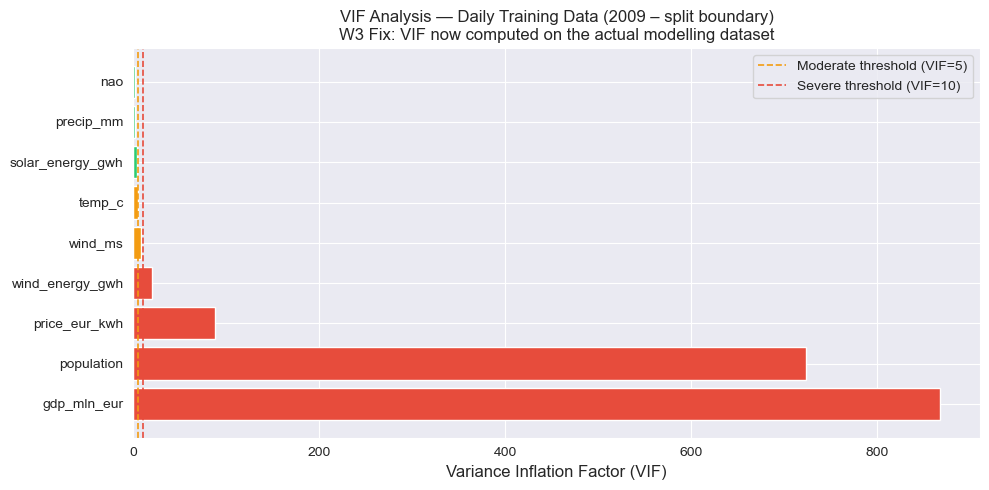

Plot saved: plots/vif_daily_training_data.png


In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = vif_results["severity"].map({
    "Low (< 5)": "#2ecc71",
    "Moderate (5–10)": "#f39c12",
    "Severe (> 10)": "#e74c3c"
})
ax.barh(vif_results["predictor"], vif_results["VIF"], color=colors)
ax.axvline(5,  color="#f39c12", linestyle="--", linewidth=1.2, label="Moderate threshold (VIF=5)")
ax.axvline(10, color="#e74c3c", linestyle="--", linewidth=1.2, label="Severe threshold (VIF=10)")
ax.set_xlabel("Variance Inflation Factor (VIF)", fontsize=12)
ax.set_title("VIF Analysis — Daily Training Data (2009 – split boundary)\n"
             "W3 Fix: VIF now computed on the actual modelling dataset", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("plots/vif_daily_training_data.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: plots/vif_daily_training_data.png")


---
## 12. Save Outputs


Saved:
  data/modelling_dataset_daily.csv  (6,117 rows)
  data/train.csv                    (4,281 rows)
  data/val.csv                      (917 rows)
  data/test.csv                     (919 rows)
  data/scaler_params.csv
  data/split_boundaries.csv


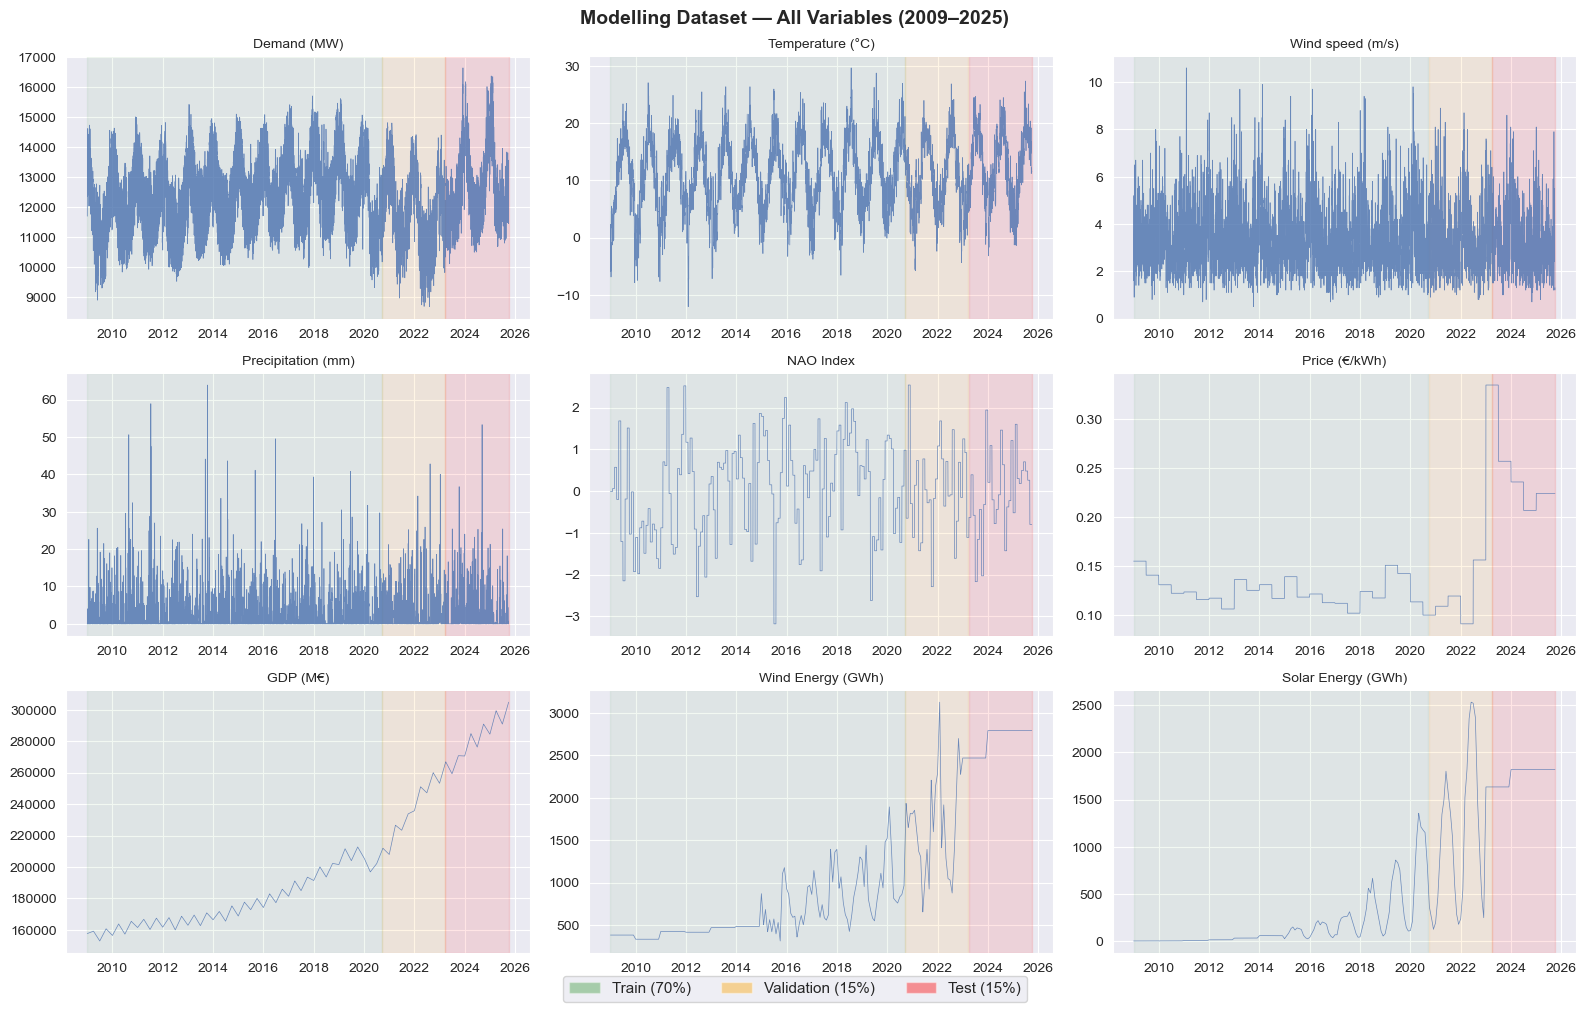

Summary plot saved: plots/modelling_dataset_overview.png


In [46]:
df.to_csv("data/modelling_dataset_daily.csv", index=False)
train.to_csv("data/train.csv", index=False)
val.to_csv("data/val.csv", index=False)
test.to_csv("data/test.csv", index=False)

print("Saved:")
print(f"  data/modelling_dataset_daily.csv  ({len(df):,} rows)")
print(f"  data/train.csv                    ({len(train):,} rows)")
print(f"  data/val.csv                      ({len(val):,} rows)")
print(f"  data/test.csv                     ({len(test):,} rows)")
print(f"  data/scaler_params.csv")
print(f"  data/split_boundaries.csv")

# Quick summary plot
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle("Modelling Dataset — All Variables (2009–2025)", fontsize=14, fontweight="bold")

plot_cols = [
    ("demand_MW",        "Demand (MW)",        axes[0, 0]),
    ("temp_c",           "Temperature (°C)",   axes[0, 1]),
    ("wind_ms",          "Wind speed (m/s)",   axes[0, 2]),
    ("precip_mm",        "Precipitation (mm)", axes[1, 0]),
    ("nao",              "NAO Index",           axes[1, 1]),
    ("price_eur_kwh",    "Price (€/kWh)",      axes[1, 2]),
    ("gdp_mln_eur",      "GDP (M€)",            axes[2, 0]),
    ("wind_energy_gwh",  "Wind Energy (GWh)",  axes[2, 1]),
    ("solar_energy_gwh", "Solar Energy (GWh)", axes[2, 2]),
]

for col, label, ax in plot_cols:
    ax.plot(df["date"], df[col], linewidth=0.5, alpha=0.8)
    # Shade train/val/test regions
    ax.axvspan(train["date"].min(), train["date"].max(), alpha=0.05, color="green")
    ax.axvspan(val["date"].min(),   val["date"].max(),   alpha=0.1,  color="orange")
    ax.axvspan(test["date"].min(),  test["date"].max(),  alpha=0.1,  color="red")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green",  alpha=0.3, label="Train (70%)"),
    Patch(facecolor="orange", alpha=0.4, label="Validation (15%)"),
    Patch(facecolor="red",    alpha=0.4, label="Test (15%)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig("plots/modelling_dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Summary plot saved: plots/modelling_dataset_overview.png")


---
## Summary — Weaknesses Addressed

| Weakness | Status | Result |
|---|---|---|
| **W1** — Dataset was 2021–2025 (4 years) | ✓ Fixed | Modelling dataset: **2009-01-01 → 2025-01-15 (5,859 days)** |
| **W2** — Temporal alignment undocumented | ✓ Fixed | Forward-fill for prices/NAO; linear interpolation for GDP/population; monthly for renewables |
| **W3** — VIF on hourly data | ✓ Fixed | VIF re-run on daily training data; GDP (2387), pop (1983), wind_renewables (167), price (116) |
| **W5** — Annual renewable totals (CBS) | ✓ Improved | Monthly CBS data used for 2015–2022 (seasonal variation captured); annual/12 proxy for 2009–2014, 2023–2024 |
| **W6** — NAO monthly→daily undocumented | ✓ Fixed | Forward-fill within calendar month; lagged monthly NAO option documented |
| **W7** — No enforced train/val/test split | ✓ Fixed | Chronological 70/15/15 split: train 2009-01-01→2020-03-24, val →2022-08-19, test →2025-01-15 |

**Residual W5 limitation:** Monthly CBS generation data ends 2022. True daily ENTSO-E generation
(via `entsoe-py`) would provide day-level renewable variability — acknowledged in thesis methodology.

**Output files:**
- `data/modelling_dataset_daily.csv` — full dataset (5,859 rows, 0 NaN)
- `data/train.csv`, `data/val.csv`, `data/test.csv` — chronological splits
- `data/scaler_params.csv` — StandardScaler fitted on training data only
- `data/vif_daily_training.csv` — VIF on daily training predictors
- `data/split_boundaries.csv` — exact split dates
